
# Stochastic Differential Equations (SDE) Simulator — Brownian Motion & Ornstein–Uhlenbeck

**Goal:** Provide a minimal, well-documented SDE simulator in Python for:
- Standard Brownian Motion (Wiener process)
- Ornstein–Uhlenbeck (OU) process

We use the **Euler–Maruyama** scheme and focus on clarity, reproducibility, and basic diagnostics.


In [10]:

# %% [markdown]
# ## 1. Environment & Utilities

import numpy as np
import math
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

def set_seed(seed: int = 42):
    """Set the global RNG seed for reproducibility."""
    global rng
    rng = np.random.default_rng(seed)
    return rng



## 2. Theory Refresher

- **Brownian Motion (Wiener process)**: 
  \( dX_t = dW_t \). In discrete time with step \(\Delta t\):
  \( X_{t+\Delta t} = X_t + \sqrt{\Delta t}\,\epsilon_t \), with \(\epsilon_t \sim \mathcal{N}(0,1)\).

- **Ornstein–Uhlenbeck (OU) process)**:
  \( dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t \). Mean-reverting to \(\mu\) with speed \(\theta\).

- **Euler–Maruyama scheme** (generic SDE \( dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t \)):
  \( X_{t+\Delta t} = X_t + a(X_t,t)\,\Delta t + b(X_t,t)\,\sqrt{\Delta t}\,\epsilon_t \).


In [11]:

# ## 3. Discretization Helpers (Euler–Maruyama)

from typing import Callable, Tuple

def euler_maruyama(
    drift: Callable[[np.ndarray, float], np.ndarray],
    diffusion: Callable[[np.ndarray, float], np.ndarray],
    x0: float,
    T: float,
    n_steps: int,
    rng_local=None
) -> Tuple[np.ndarray, np.ndarray]:
    """Simulate an SDE path with Euler–Maruyama.
    
    Args:
        drift: function a(x, t) returning the drift (shape-compatible with x).
        diffusion: function b(x, t) returning the diffusion coefficient.
        x0: initial state (scalar or 1D array).
        T: total time horizon.
        n_steps: number of steps (time grid size is n_steps+1 including t=0).
        rng_local: numpy Generator for randomness (optional).
        
    Returns:
        t: array of shape (n_steps+1,) with time points.
        x: array of shape (n_steps+1,) with the simulated path.
    """
    if rng_local is None:
        rng_local = rng
    
    dt = T / n_steps
    t = np.linspace(0.0, T, n_steps + 1)
    x = np.zeros(n_steps + 1, dtype=float)
    x[0] = x0
    
    for i in range(n_steps):
        xi = x[i]
        ti = t[i]
        a = drift(xi, ti)
        b = diffusion(xi, ti)
        dW = math.sqrt(dt) * rng_local.standard_normal()
        x[i+1] = xi + a * dt + b * dW
    
    return t, x


In [12]:

# ## 4. Brownian Motion (Wiener Process)

def brownian_drift(x: float, t: float) -> float:
    """Drift for standard Brownian motion: 0."""
    return 0.0

def brownian_diffusion(x: float, t: float) -> float:
    """Diffusion for standard Brownian motion: 1."""
    return 1.0

def simulate_brownian(x0: float = 0.0, T: float = 1.0, n_steps: int = 1000, seed: int = 42):
    """Simulate one Brownian path using Euler–Maruyama."""
    rng_local = np.random.default_rng(seed)
    return euler_maruyama(brownian_drift, brownian_diffusion, x0, T, n_steps, rng_local)


In [13]:

# ## 5. Ornstein–Uhlenbeck (OU) Process

def ou_drift(theta: float, mu: float):
    """Return a drift function a(x, t) = theta * (mu - x)."""
    def _drift(x: float, t: float) -> float:
        return theta * (mu - x)
    return _drift

def ou_diffusion(sigma: float):
    """Return a diffusion function b(x, t) = sigma (constant)."""
    def _diff(x: float, t: float) -> float:
        return sigma
    return _diff

def simulate_ou(x0: float = 0.0, T: float = 2.0, n_steps: int = 1000,
                theta: float = 2.0, mu: float = 0.0, sigma: float = 0.5, seed: int = 123):
    """Simulate one OU path using Euler–Maruyama."""
    rng_local = np.random.default_rng(seed)
    drift = ou_drift(theta, mu)
    diff = ou_diffusion(sigma)
    return euler_maruyama(drift, diff, x0, T, n_steps, rng_local)


In [14]:

# ## 6. Diagnostics & Plotting

def plot_path(t: np.ndarray, x: np.ndarray, title: str):
    """Plot a single SDE path (matplotlib, single plot, default colors)."""
    plt.figure(figsize=(8, 4))
    plt.plot(t, x, label=title)
    plt.xlabel("Time")
    plt.ylabel("State")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def sample_mean_var(x: np.ndarray) -> tuple:
    """Return (mean, variance) of a path."""
    return float(np.mean(x)), float(np.var(x))


Brownian path: mean=-1.7626, var=0.6779


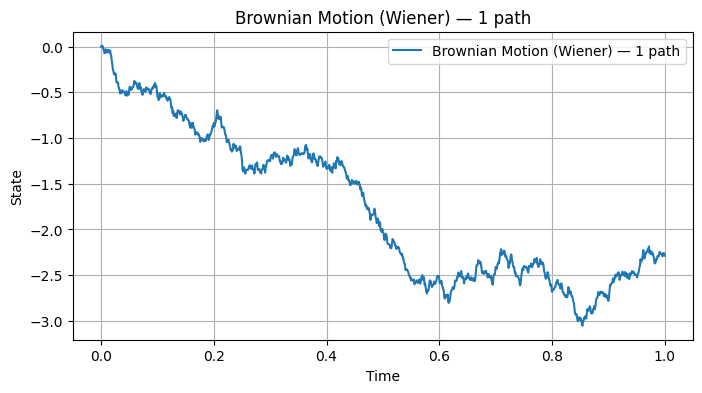

In [15]:

# %% [markdown]
# ## 7. Demo — Brownian Motion

set_seed(7)
t_bm, x_bm = simulate_brownian(x0=0.0, T=1.0, n_steps=1000, seed=7)
m_bm, v_bm = sample_mean_var(x_bm)
print(f"Brownian path: mean={m_bm:.4f}, var={v_bm:.4f}")
plot_path(t_bm, x_bm, title="Brownian Motion (Wiener) — 1 path")


OU path: mean=0.7022, var=0.1493


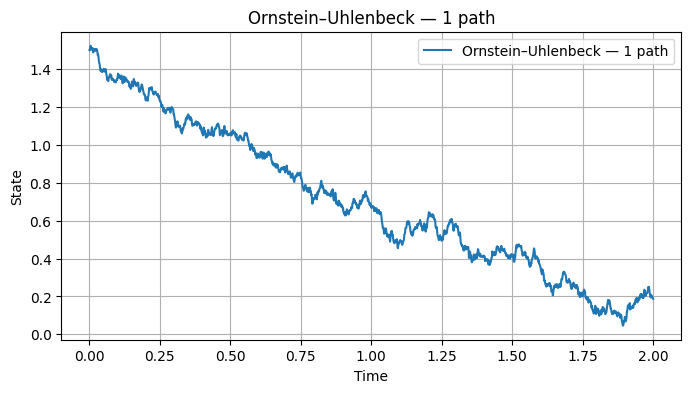

In [16]:

# ## 8. Demo — Ornstein–Uhlenbeck

t_ou, x_ou = simulate_ou(x0=1.5, T=2.0, n_steps=1500, theta=1.0, mu=0.0, sigma=0.3, seed=11)
m_ou, v_ou = sample_mean_var(x_ou)
print(f"OU path: mean={m_ou:.4f}, var={v_ou:.4f}")
plot_path(t_ou, x_ou, title="Ornstein–Uhlenbeck — 1 path")


In [17]:

# ## 9. OU Stationary Mean/Variance (Sanity Check)
# For OU: stationary mean = mu, stationary variance = sigma^2 / (2*theta).
# We'll simulate many terminal samples to compare empirical vs theoretical.

def ou_terminal_samples(n_paths=2000, T=5.0, n_steps=1000, theta=1.0, mu=0.0, sigma=0.5, seed=1234):
    rng_local = np.random.default_rng(seed)
    xs = np.empty(n_paths, dtype=float)
    drift = ou_drift(theta, mu)
    diff = ou_diffusion(sigma)
    for k in range(n_paths):
        t, x = euler_maruyama(drift, diff, x0=0.0, T=T, n_steps=n_steps, rng_local=rng_local)
        xs[k] = x[-1]
    return xs

theta, mu, sigma = 1.0, 0.0, 0.5
xs = ou_terminal_samples(n_paths=2000, T=5.0, n_steps=1000, theta=theta, mu=mu, sigma=sigma, seed=2025)
emp_mean, emp_var = float(np.mean(xs)), float(np.var(xs))
theo_mean = mu
theo_var = sigma**2 / (2.0 * theta)
print(f"Empirical mean ≈ {emp_mean:.4f} vs Theory {theo_mean:.4f}")
print(f"Empirical var  ≈ {emp_var:.4f} vs Theory {theo_var:.4f}")


Empirical mean ≈ 0.0045 vs Theory 0.0000
Empirical var  ≈ 0.1295 vs Theory 0.1250


In [18]:

# ## 10. Minimal API (Reusable Functions)
# - simulate_brownian / simulate_ou
# - euler_maruyama, ou_drift, ou_diffusion
# - plot_path

def simulate_many_paths(sim_fn, n_paths=10, **kwargs):
    """Simulate multiple paths using a sim_fn that returns (t, x)."""
    paths = []
    t_ref = None
    for i in range(n_paths):
        t, x = sim_fn(**kwargs)
        if t_ref is None:
            t_ref = t
        paths.append(x)
    return t_ref, np.stack(paths, axis=0)



## 11. Multiple Trajectories (Simulation & Plot)
This cell simulates **multiple paths** for either Brownian Motion or Ornstein–Uhlenbeck (OU) and plots the first 20 paths on a single figure.  
It also computes and plots the **time-wise ensemble mean** and a **±1 std band** for reference.  


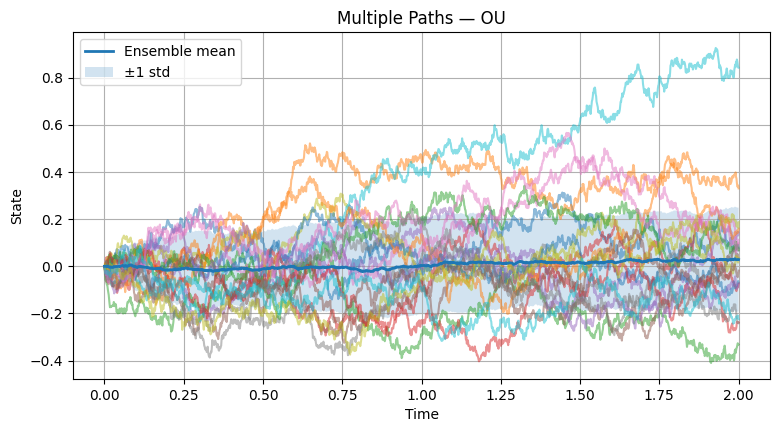

In [22]:

# Parameters
process = "ou"         # "brownian" or "ou"
n_paths = 100          # number of paths to simulate
T = 2.0                # time horizon
n_steps = 1500         # discretization steps
seed_base = 123        # base seed; each path uses seed_base + i

# OU-specific parameters (ignored for Brownian)
theta = 1.0
mu = 0.0
sigma = 0.3

# Simulation
def _sim_one(idx_seed: int):
    if process.lower() == "brownian":
        return simulate_brownian(x0=0.0, T=T, n_steps=n_steps, seed=idx_seed)
    elif process.lower() == "ou":
        return simulate_ou(x0=0.0, T=T, n_steps=n_steps, theta=theta, mu=mu, sigma=sigma, seed=idx_seed)
    else:
        raise ValueError("Unknown process. Use 'brownian' or 'ou'.")

paths = []
t_ref = None
for i in range(n_paths):
    t, x = _sim_one(seed_base + i)
    if t_ref is None:
        t_ref = t
    paths.append(x)
paths = np.stack(paths, axis=0)  # shape: (n_paths, n_steps+1)

# Plot first 20 paths
plt.figure(figsize=(9, 4.5))
for i in range(min(20, n_paths)):
    plt.plot(t_ref, paths[i], alpha=0.5)

# Ensemble statistics
mean_t = np.mean(paths, axis=0)
std_t = np.std(paths, axis=0)
plt.plot(t_ref, mean_t, linewidth=2.0, label="Ensemble mean")
plt.fill_between(t_ref, mean_t - std_t, mean_t + std_t, alpha=0.2, label="±1 std")

title = "Multiple Paths — OU" if process.lower() == "ou" else "Multiple Paths — Brownian"
plt.title(title)
plt.xlabel("Time"); plt.ylabel("State"); plt.grid(True); plt.legend()
plt.show()